In [9]:
!pip install psycopg2-binary

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 15.6 MB/s eta 0:00:0000:01m


In [116]:
# Imports & connections
import pandas as pd
import os
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from dotenv import load_dotenv

load_dotenv()
DB_URL = os.getenv('DATABASE_URL')
engine = create_engine(DB_URL)

In [117]:
# Which cause, for which the airport is made accountable, leads to how much delay by country per year?
query_delay_cause_airport = """
SELECT
    state_name,
    year,
    ROUND(SUM(dly_apt_arr_a_1), 0)  AS delay_atc_capacity,
    ROUND(SUM(dly_apt_arr_c_1), 0)  AS delay_staffing,
    ROUND(SUM(dly_apt_arr_w_1), 0)  AS delay_weather,
    ROUND(SUM(dly_apt_arr_e_1), 0)  AS delay_equipment,
    ROUND(SUM(dly_apt_arr_s_1), 0)  AS delay_special_event,
    ROUND(SUM(dly_apt_arr_t_1), 0)  AS delay_routeing,
    ROUND(SUM(dly_apt_arr_g_1), 0)  AS delay_aerodrome,
    ROUND(SUM(dly_apt_arr_m_1), 0)  AS delay_met,
    ROUND(SUM(dly_apt_arr_i_1), 0)  AS delay_industrial_action,
    ROUND(SUM(dly_apt_arr_na_1), 0) AS delay_unclassified,
    ROUND(SUM(dly_apt_arr_1), 0)    AS total_delay
FROM fact_airport_delay
GROUP BY state_name, year
ORDER BY year DESC, total_delay DESC;
"""

df_delay_cause_airport = pd.read_sql(query_delay_cause_airport, engine)


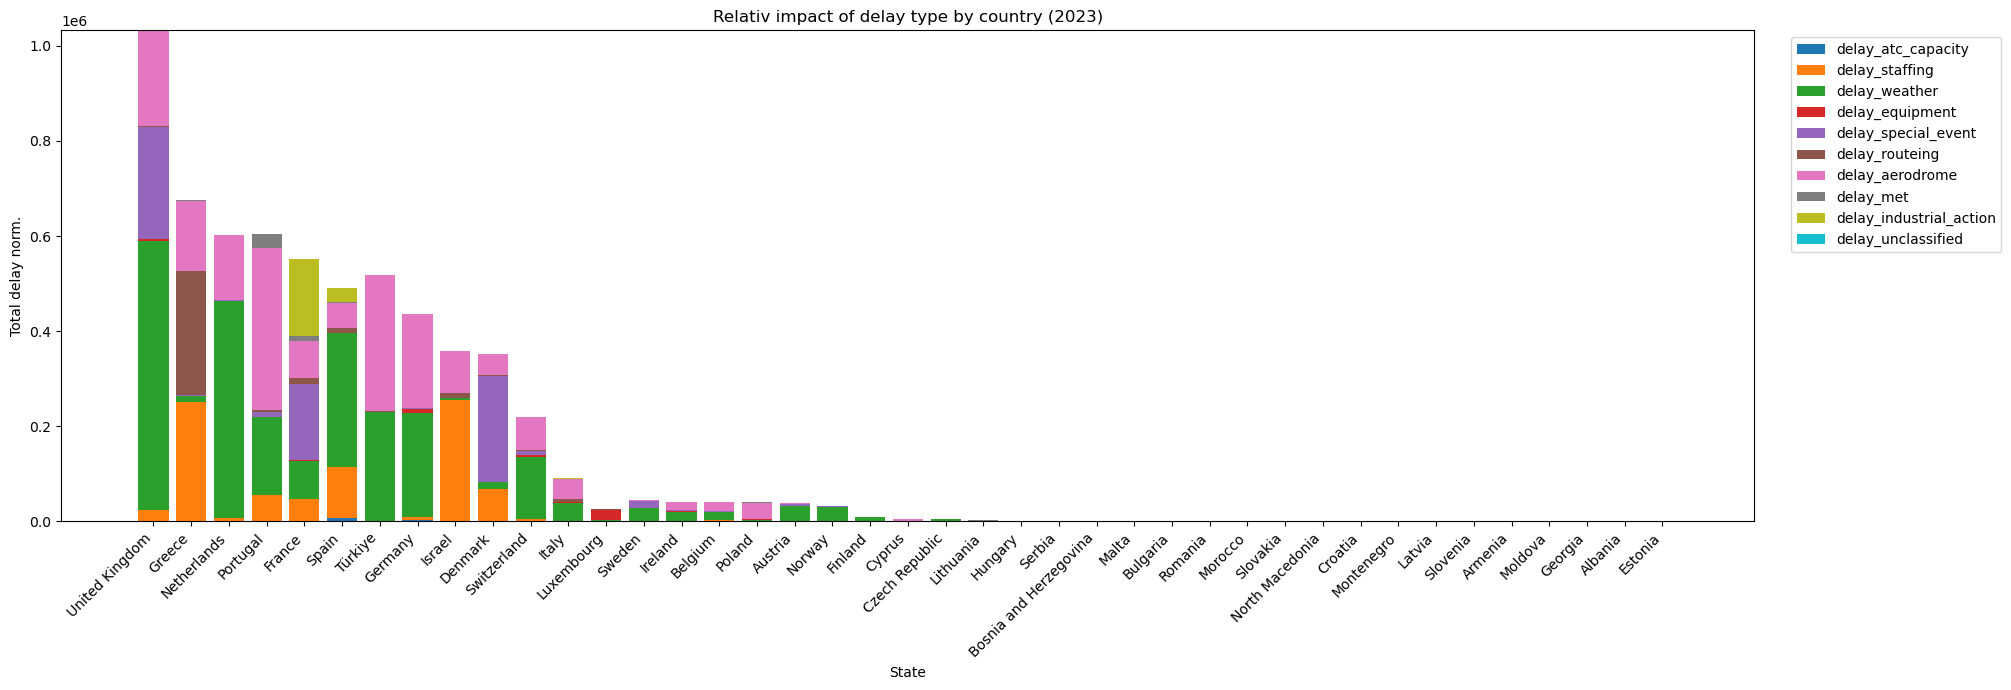

In [118]:
## Analysis & Visualisation
# check which rows contain NaN
# df_delay_cause_airport[df_delay_cause_airport.isna().any(axis=1)]
# -> 92 rows
# validate if entire row is NaN
# df_delay_cause_airport[df_delay_cause_airport.isna().any(axis=1)].tail(50)
# df_delay_cause_airport[df_delay_cause_airport.isna().any(axis=1)].head(50)
# -> all of the 92 rows contain just NaN
# -> drop
df_delay_cause_airport = df_delay_cause_airport.dropna(how='any')

# Check and set unified state_name
# countries_sorted = sorted(df_delay_cause_airport["state_name"].unique())
# Turkey is written and presend in 3 different ways of typing
# 'Turkey', 'Turkiye', 'Türkiye'
# -> Türkiye is the official (beginning 2022)
# Set Türkiye
df_delay_cause_airport["state_name"] = df_delay_cause_airport["state_name"].replace({
    "Turkey": "Türkiye",
    "Turkiye": "Türkiye"
})

# Set year filter

year_filter = 2023
df_delay_cause_airport_filtered = df_delay_cause_airport[df_delay_cause_airport["year"] == year_filter]

# Define delay types in a list
delay_cols = [
    "delay_atc_capacity", "delay_staffing", "delay_weather", "delay_equipment",
    "delay_special_event", "delay_routeing", "delay_aerodrome", "delay_met",
    "delay_industrial_action", "delay_unclassified"
]

# Plot
fig, ax = plt.subplots(figsize=(20, 7))

bottom = [0] * len(df_delay_cause_airport_filtered)

for col in delay_cols:
    ax.bar(df_delay_cause_airport_filtered["state_name"], df_delay_cause_airport_filtered[col], label=col, bottom=bottom)
    bottom = [b + v for b, v in zip(bottom, df_delay_cause_airport_filtered[col].fillna(0))]

ax.set_xlabel("Country")
ax.set_ylabel("Total delay norm.")
ax.set_title(f"Relativ impact of delay type by country ({year_filter})")
ax.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

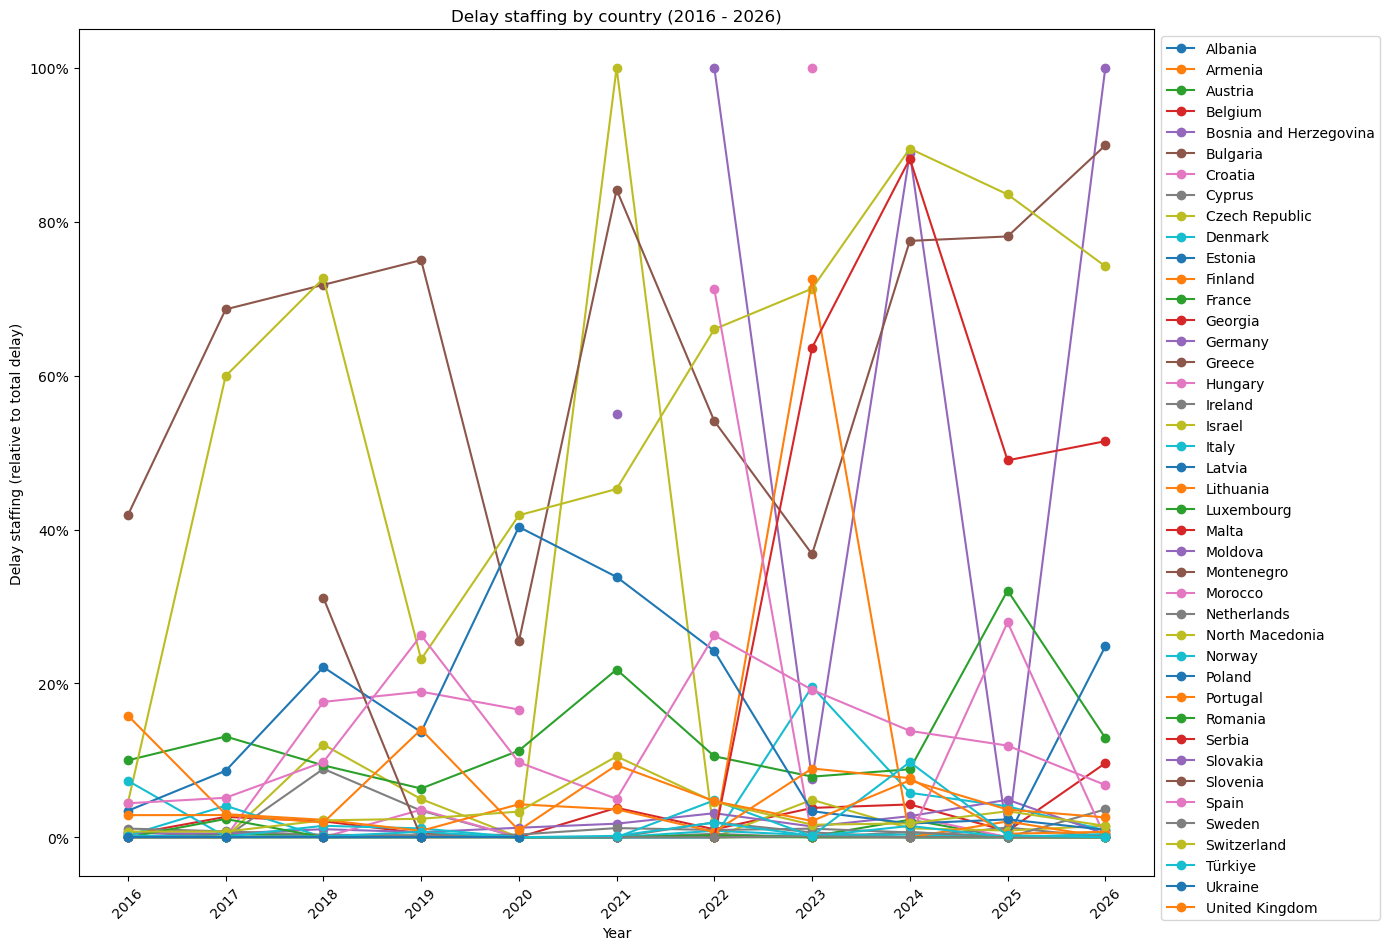

In [119]:
# impact of epidemic (corona) by comparing corona period to non-corona 
df_delay_cause_airport = df_delay_cause_airport.groupby(["state_name", "year"]).sum()

df_delay_cause_airport_reset = df_delay_cause_airport.reset_index()

# Define year range
years_def = range(2016, 2027)

fig, ax = plt.subplots(figsize=(14, 6))

for country, group in df_delay_cause_airport_reset.groupby("state_name"):
    # Reindex auf alle Jahre, fehlende Jahre = 0
    group = group.set_index("year").reindex(years_def) # ,fill_value=0
    ratio = group["delay_staffing"] / group["total_delay"].replace(0, float("nan")) # if ratio = 0, plot is skipped
    ax.plot(years_def, ratio, label=country, marker="o")

ax.set_xlabel("Year")
ax.set_ylabel("Delay staffing (relative to total delay)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.set_title(f"Delay staffing by country ({years_def[0]} - {years_def[-1]})")
ax.set_xticks(years_def)
# ax.set_yscale("log")
ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.xticks(rotation=45)
ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
n_countries = df_delay_cause_airport_reset["state_name"].nunique()
fig.set_size_inches(14, max(6, n_countries * 1))
plt.show()

In [120]:
# Which cause, for which the airspace of the airport is made accountable, leads to how much delay by country per year?
# Optional: include months to have a closer look
query_delay_cause_airspace = """
SELECT
    er.country_name,
    ed.year,
    ed.month_num,
    ROUND(SUM(ed.dly_ert_a_1), 0)  AS delay_atc_capacity,
    ROUND(SUM(ed.dly_ert_c_1), 0)  AS delay_staffing,
    ROUND(SUM(ed.dly_ert_w_1), 0)  AS delay_weather,
    ROUND(SUM(ed.dly_ert_e_1), 0)  AS delay_equipment,
    ROUND(SUM(ed.dly_ert_s_1), 0)  AS delay_special_event,
    ROUND(SUM(ed.dly_ert_t_1), 0)  AS delay_routeing,
    ROUND(SUM(ed.dly_ert_g_1), 0)  AS delay_aerodrome,
    ROUND(SUM(ed.dly_ert_m_1), 0)  AS delay_met,
    ROUND(SUM(ed.dly_ert_i_1), 0)  AS delay_industrial_action,
    ROUND(SUM(ed.dly_ert_na_1), 0) AS delay_unclassified,
    ROUND(SUM(ed.dly_ert_1), 0)    AS total_delay
FROM fact_enroute_delay ed
INNER JOIN dim_entity_region er USING(entity_name)
GROUP BY er.country_name, ed.year, ed.month_num
ORDER BY ed.year DESC, total_delay DESC;
"""

df_delay_cause_airspace = pd.read_sql(query_delay_cause_airspace, engine)
df_delay_cause_airspace = df_delay_cause_airspace.dropna(how='any')

In [121]:
# Year filter
df_delay_cause_airspace_year = df_delay_cause_airspace.groupby(["country_name", "year"]).sum()
df_delay_cause_airspace_year = df_delay_cause_airspace_year.drop(columns=["month_num"])

In [122]:
df_delay_cause_airspace_year.head(20)

delay_atc_capacity  delay_staffing  delay_weather  \
country_name year                                                      
Albania      2017                 0.0             0.0            0.0   
             2018                 0.0             0.0            0.0   
             2019                 0.0             0.0            0.0   
             2021                 0.0             0.0            0.0   
             2022                 0.0           119.0            0.0   
             2023                 0.0             0.0         1530.0   
             2024                 0.0          3663.0        22964.0   
             2025                 0.0          4326.0         3829.0   
Austria      2016                 0.0          2956.0        44901.0   
             2017                 0.0         39762.0       174522.0   
             2018                 0.0        203294.0       445029.0   
             2019                 0.0        626018.0       717487.0   
             2020                 0.0            85.0            4.0   
             2021                 0.0             0.0          951.0   
             2022                 0.0         11849.0        58202.0   
             2023                 0.0         39963.0        96871.0   
             2024                 0.0        107897.0       433439.0   
             2025                 0.0         35978.0       282019.0   
             2026                 0.0             5.0         1978.0   
Azerbaijan   2026                 0.0             0.0            0.0   

                   delay_equipment  delay_special_event  delay_routeing  \
country_name year                                                         
Albania      2017              0.0                  0.0            80.0   
             2018              0.0                  0.0             0.0   
             2019              0.0                  0.0             0.0   
             2021              0.0                 33.0             0.0   
             2022              0.0                  0.0             0.0   
             2023              0.0                  0.0           302.0   
             2024              0.0                  0.0          3704.0   
             2025              0.0                  0.0          3145.0   
Austria      2016              0.0               5525.0             0.0   
             2017              0.0              30742.0             0.0   
             2018              0.0             156470.0          1446.0   
             2019              0.0             403059.0           287.0   
             2020              0.0                  0.0             0.0   
             2021              0.0                  0.0             0.0   
             2022              0.0              34785.0            41.0   
             2023              0.0              26743.0             0.0   
             2024              0.0              98452.0           805.0   
             2025              0.0             231080.0             0.0   
             2026              0.0                  0.0             0.0   
Azerbaijan   2026              0.0                147.0             0.0   

                   delay_aerodrome  delay_met  delay_industrial_action  \
country_name year                                                        
Albania      2017              0.0        0.0                      0.0   
             2018              0.0        0.0                      0.0   
             2019              0.0      195.0                      0.0   
             2021              0.0        0.0                      0.0   
             2022              0.0        0.0                      0.0   
             2023              0.0        0.0                      0.0   
             2024            202.0        0.0                      0.0   
             2025              0.0        0.0                      0.0   
Austria      2016              0.0        0

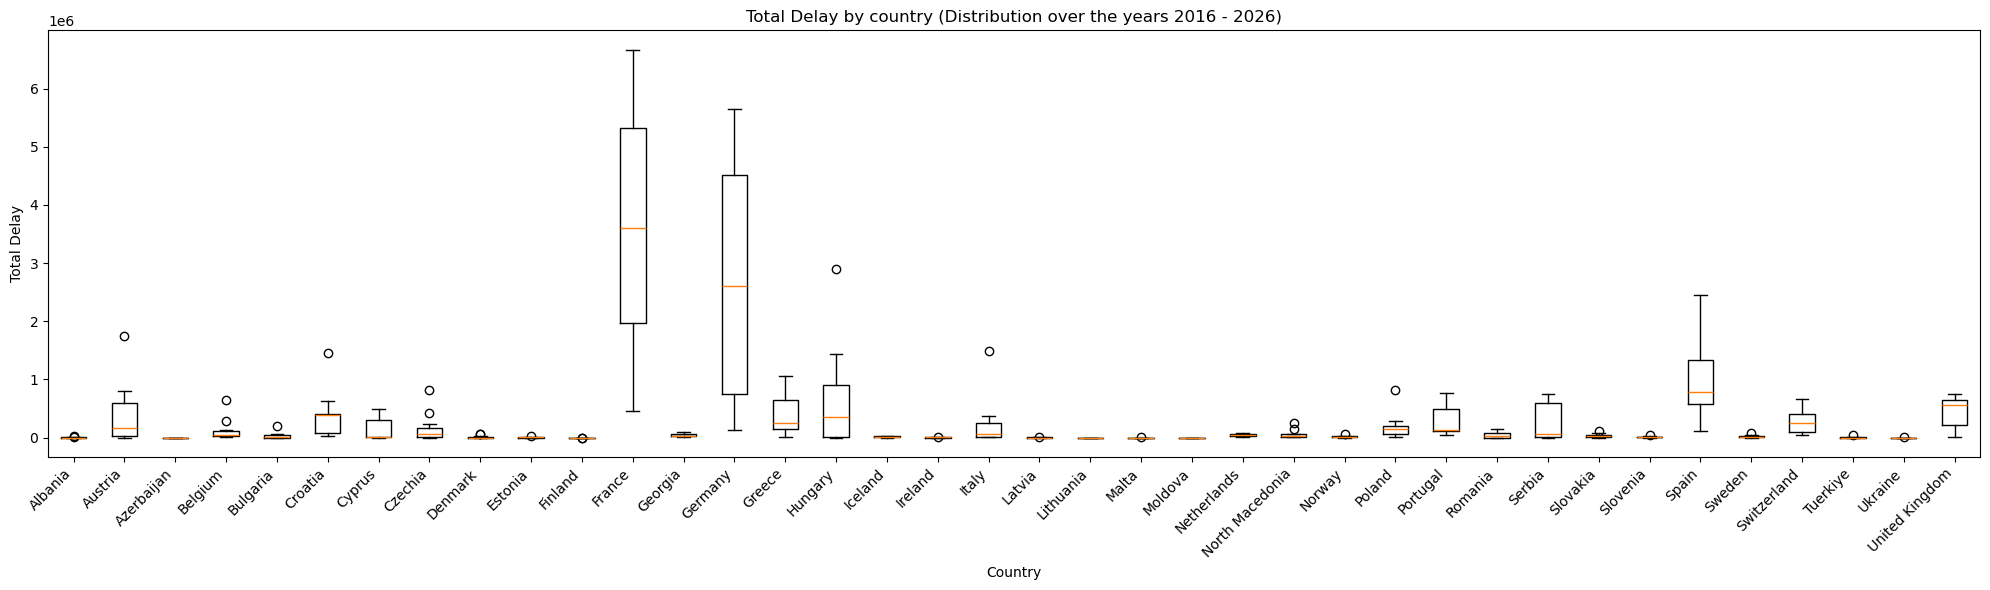

In [123]:
# Reset index
df_delay_cause_airspace_year = df_delay_cause_airspace_year.reset_index()

# countries
countries_delay_cause_airspace = df_delay_cause_airspace_year["country_name"].unique()

# Boxplot data: one array per country
data = [df_delay_cause_airspace_year[df_delay_cause_airspace_year["country_name"] == c]["total_delay"].values for c in countries_delay_cause_airspace]

# Plot
fig, ax = plt.subplots(figsize=(20, 6))

ax.boxplot(data, tick_labels=countries_delay_cause_airspace, vert=True)

ax.set_xlabel("Country")
ax.set_ylabel("Total delay")
ax.set_title("Total delay by country (Distribution over the years 2016 - 2026)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [124]:
# Month avg
# correlation to weather and/or holidays possible
df_delay_cause_airspace_month_avg = df_delay_cause_airspace.groupby(["country_name", "month_num"]).mean()
df_delay_cause_airspace_month_avg = df_delay_cause_airspace_month_avg.sort_values(["country_name", "month_num"]).drop(columns=["year"])
df_delay_cause_airspace_month_avg.head(20)

delay_atc_capacity  delay_staffing  delay_weather  \
country_name month_num                                                      
Albania      1                         0.0        0.000000       0.000000   
             2                         0.0        0.000000       0.000000   
             4                         0.0        0.000000       0.000000   
             5                         0.0        0.000000       0.000000   
             6                         0.0      503.750000     315.000000   
             7                         0.0      945.500000    2710.750000   
             8                         0.0     1155.500000    3914.500000   
             9                         0.0        0.000000    2017.000000   
             10                        0.0        0.000000    2340.000000   
             11                        0.0        0.000000       0.000000   
             12                        0.0        0.000000       0.000000   
Austria      1                         0.0      210.600000      29.100000   
             2                         0.0       73.200000       0.000000   
             3                         0.0      547.125000       0.000000   
             4                         0.0     2240.625000    2209.000000   
             5                         0.0    18443.875000   22714.875000   
             6                         0.0    25164.777778   60351.666667   
             7                         0.0    30332.888889   82000.555556   
             8                         0.0    21982.100000   63702.700000   
             9                         0.0    13890.555556   14537.444444   

                        delay_equipment  delay_special_event  delay_routeing  \
country_name month_num                                                         
Albania      1                      0.0             0.000000        0.000000   
             2                      0.0             0.000000        0.000000   
             4                      0.0            33.000000        0.000000   
             5                      0.0             0.000000        0.000000   
             6                      0.0             0.000000      881.250000   
             7                      0.0             0.000000      786.250000   
             8                      0.0             0.000000        0.000000   
             9                      0.0             0.000000        0.000000   
             10                     0.0             0.000000      561.000000   
             11                     0.0             0.000000        0.000000   
             12                     0.0             0.000000        0.000000   
Austria      1                      0.0            48.000000        0.000000   
             2                      0.0            32.200000        0.000000   
             3                      0.0          4835.125000        0.000000   
             4                      0.0          4173.250000        0.000000   
             5                      0.0          7091.250000       14.250000   
             6                      0.0         12945.000000        0.000000   
             7                      0.0         37279.000000        0.000000   
             8                      0.0         23936.500000      230.200000   
             9                      0.0          9381.555556       18.111111   

                        delay_aerodrome  delay_met  delay_industrial_action  \
country_name month_num                                                        
Albania      1                 0.000000  64.000000                      0.0   
             2                 0.000000   0.000000                      0.0   
             4                 0.000000   0.000000                      0.0   
             5                 0.000000   0.000000                      0.0   
             6                 0.000000   0.000000                      0.0   
             7 